# Data Generator Test

This notebook demonstrates and tests the SyntheticDataGenerator class, which is a wrapper for generating synthetic time series data using multiple modular components.

## Test Summary

This notebook has tested the main functionality of the SyntheticDataGenerator class including:

1. **Basic generation** - Standard time series generation with all components
2. **Normalization** - Min-max and standardization normalization methods
3. **Change points** - Regime changes and nonstationary behavior
4. **Missing data** - Random missing value introduction and interpolation
5. **Confounding** - Variable removal for confounding simulation
6. **Nonstationarity** - Continuity constraints between regime changes 
7. **Structure dropping** - Alternating periods with and without causal structure
8. **Performance** - Generation speed and robustness testing


In [4]:
import sys

sys.path.append("../..")

from data_generator import SyntheticDataGenerator
from components.noise_generator import NoiseGenerator
from components.nl_sampler import NL_function_generator
from components.lagged_effects import LaggedEffects
from components.instantanous_effects import InstantanousEffects
from components.exog_influences import ExogenousInfluences

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Basic Setup and Component Configuration

First, let's set up the basic components needed for the data generator.

In [5]:
# Set up basic parameters
n_variables = 4
time_series_length = 500
# Initialize random number generator
rng = 42

In [6]:
# Set up innovation noise generator
innovation_noise = NoiseGenerator(modus="inno", additive=True, rng=rng)

# Set up observation noise generator
observation_noise = NoiseGenerator(modus="obs", additive=True, snr=5, rng=rng)

In [7]:
# Set up nonlinear function generator
nl_generator = NL_function_generator(
    nl_mode="power_set", power_dist=[0.5, 0.6, 1.9, 2], which_power_dist="all", rng=rng
)

In [12]:
# Set up linear structural equation model
lagged_effects = LaggedEffects(
    n_vars=n_variables, link_proba=0.15, max_lags=3, nonlinear_proba=0.0, rng=rng
)

# Set up instantaneous, potentially, nonlinear effects
instantaneous_effects = InstantanousEffects(
    n_vars=n_variables,
    link_proba=0.2,
    nonlinear_proba=0.5,
    nl_sampler=nl_generator,
    rng=rng,
)

# Set up empty exogenous influences
exogenous_influences = ExogenousInfluences(
    n_vars=n_variables, n_exogs=2, link_proba=0.0, rng=rng
)

## Test 1: Basic Data Generation

Let's test the basic functionality of the data generator.

In [14]:
# Create the synthetic data generator
data_generator = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=time_series_length,
    normalize=None,
)

# Generate a sample
sample_data, lagged_y, inst_y, exog_y, exog_ts, nl_struc, nl_inst, nl_exog, resampling_stats = (
    data_generator.get_sample()
)

print(f"Variables: {sample_data.shape[0]}")
print(f"Time steps: {sample_data.shape[1]}")

Attempt 1: The VAR process is not stable. Reinitializing with new random links.
Attempt 2: The VAR process is not stable. Reinitializing with new random links.
break!
  Resampling section 0 (attempt 2)
Variables: 4
Time steps: 500


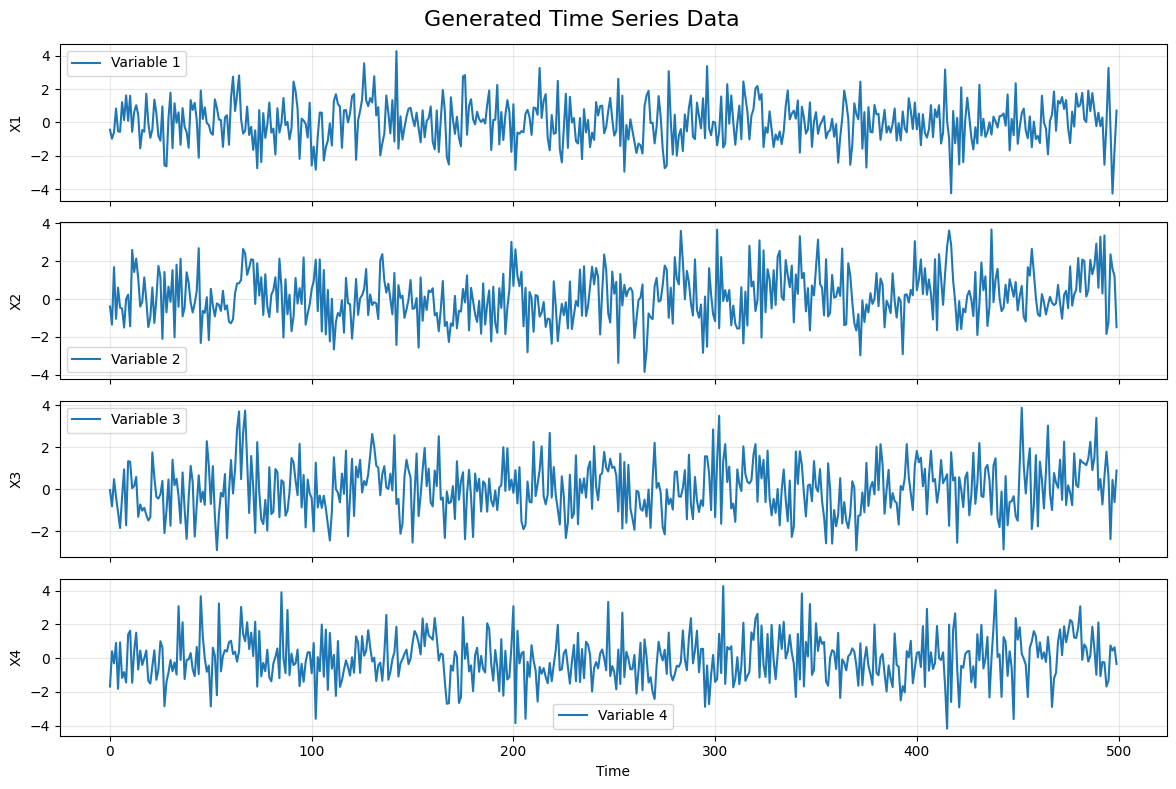

In [15]:
# Visualize the generated time series
fig, axes = plt.subplots(n_variables, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Generated Time Series Data", fontsize=16)

for i in range(n_variables):
    axes[i].plot(sample_data[i], label=f"Variable {i + 1}")
    axes[i].set_ylabel(f"X{i + 1}")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Test 2: Data Generation with Normalization

Test different normalization methods.

In [19]:
# Test with min-max normalization
generator_none = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=time_series_length,
    normalize=None,
)
data_none = generator_none.get_sample()
print("Max value without min-max normalization:", data_none[0].max())


# Test with min-max normalization
generator_minmax = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=time_series_length,
    normalize="minmax",
)

data_minmax = generator_minmax.get_sample()
print("Max value after min-max normalization:", data_minmax[0].max())

# Test with standardization
generator_std = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=time_series_length,
    normalize="standardization",
)

data_std = generator_std.get_sample()
print("Ex1 after standardization:", data_std[0][0].mean(), data_std[0][0].std())
print("Ex2 after standardization:", data_std[0][1].mean(), data_std[0][1].std())

Attempt 1: The VAR process is not stable. Reinitializing with new random links.
Max value without min-max normalization: 4.089376531545878
Max value after min-max normalization: 1.0
Ex1 after standardization: 0.0 0.9999999999999999
Ex2 after standardization: -1.7763568394002505e-17 0.9999999999999999


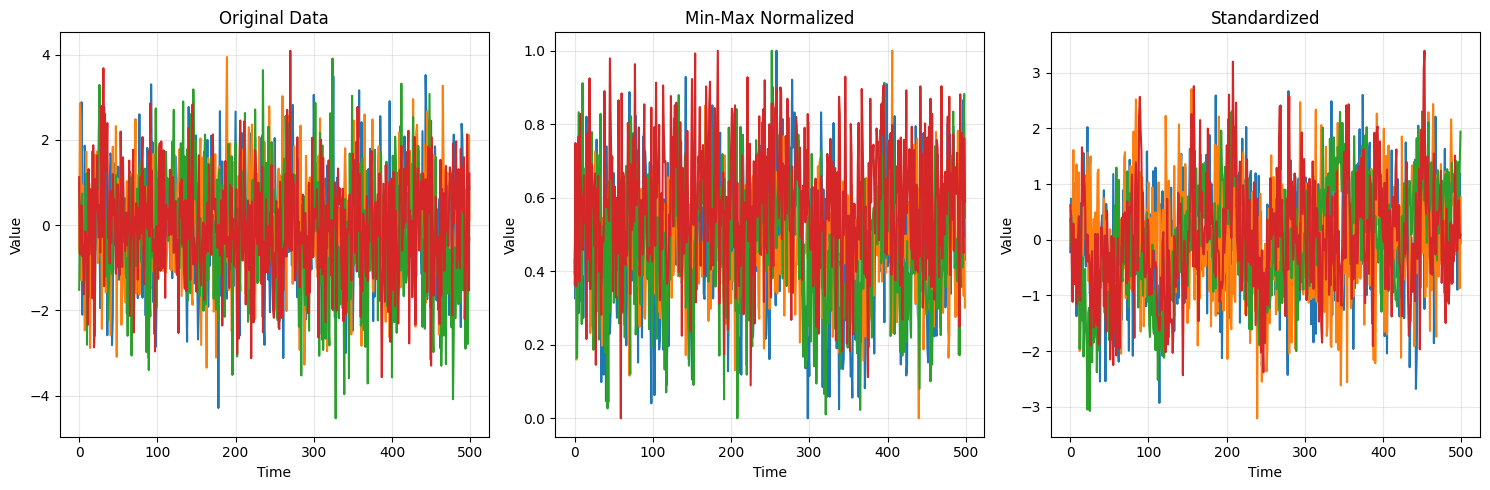

In [20]:
# Compare normalization effects
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original data
axes[0].plot(data_none[0].T)
axes[0].set_title("Original Data")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

# Min-max normalized
axes[1].plot(data_minmax[0].T)
axes[1].set_title("Min-Max Normalized")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Value")
axes[1].grid(True, alpha=0.3)

# Standardized
axes[2].plot(data_std[0].T)
axes[2].set_title("Standardized")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Value")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Test 3: Change Points and Regime Changes

Test the ability to handle change points in the data generation process.

Change points: [200, 200, 200]


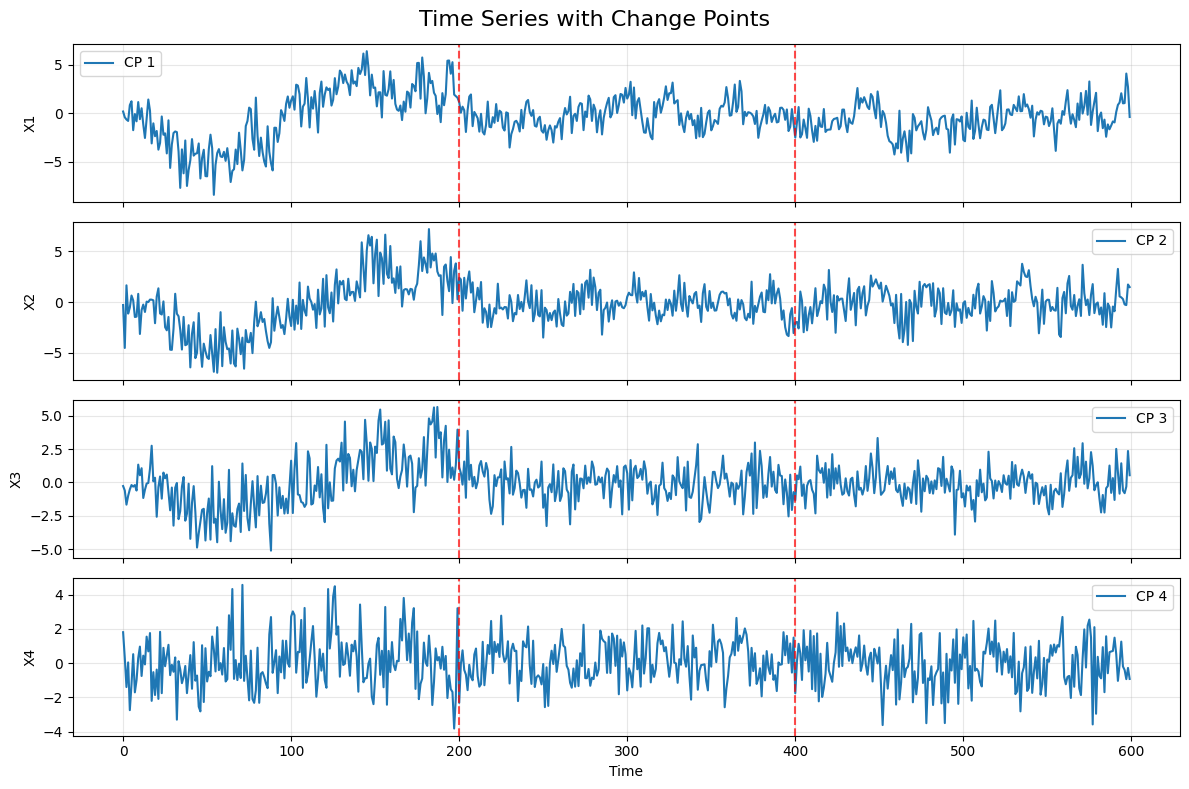

In [23]:
# Create generator with change points (Changepoints currently reset every component)
change_points = [200, 400]  # Change points at time steps 200 and 400

generator_changepoints = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=600,  # Longer series to see change points
    change_points=change_points,
    nonstationary=True,
)

data_changepoints = generator_changepoints.get_sample()

# Visualize the data with change points
fig, axes = plt.subplots(n_variables, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Time Series with Change Points", fontsize=16)

for n in range(n_variables):
    axes[n].plot(data_changepoints[0][n], label=f"CP {n + 1}")
    axes[n].set_ylabel(f"X{n + 1}")
    axes[n].grid(True, alpha=0.3)
    axes[n].legend()

    # Mark change points
    for cp in change_points:
        axes[n].axvline(x=cp, color="red", linestyle="--", alpha=0.7)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Test 4: Missing Data and Interpolation

Test the missing data functionality.

In [27]:
# Create generator with missing data interpolation
generator_missing = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=time_series_length,
    interpolate=0.1,  # 10% missing data
)

data_missing = generator_missing.get_sample()

print(f"Generated data with missing values: {data_missing[0].shape}")
print(f"Any NaN values remaining: {np.isnan(data_missing[0]).any()}")

Generated data with missing values: (4, 500)
Any NaN values remaining: False


/home/stein/project_repos/tcd_arena/synthetic_ds_generator/resources/additional_notebooks/../../data_generator.py:516: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")


## Test 5: Confounding Variables

Test the confounding variable removal functionality.

In [28]:
# Create generator that removes variables for confounding
generator_confounding = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=time_series_length,
    remove_n_variables_for_confounding=1,  # Remove 1 variable
)

data_confounding = generator_confounding.get_sample()

print(f"Original variables: {n_variables}")
print(f"Variables after confounding removal: {data_confounding[0].shape[0]}")
print(f"Observed variables shape: {data_confounding[0].shape}")

Original variables: 4
Variables after confounding removal: 3
Observed variables shape: (3, 500)


## Test 6: Nonstationarity Parameter

Test the `nonstationarity` parameter which controls whether the structural model can change between regimes at change points. When `nonstationarity=True`, the generator uses the previous structural links as a restriction mask to ensure some continuity between regimes.

In [29]:
# Test With nonstationarity (default behavior)
# Each regime change generates completely new structural links
print("Testing nonstationarity=False (default):")

generator_stationary = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=600,
    change_points=[200, 400],
    nonstationary=False,  # Default behavior
)

data_stationary = generator_stationary.get_sample()
links_stationary = data_stationary[1]  # Structural links for each regime

print(f"Number of regimes: {links_stationary.shape[0]}")
print(f"Links shape per regime: {links_stationary.shape[1:]}")

# Compare links between regimes
print("\nStructural links comparison between regimes:")
for i in range(links_stationary.shape[0]):
    print(f"Regime {i + 1} - Total links: {np.sum(links_stationary[i] != 0)}")
    if i > 0:
        # Compare with previous regime
        same_links = np.sum((links_stationary[i] != 0) & (links_stationary[i - 1] != 0))
        print(f"  Links shared with regime {i}: {same_links}")

print("\nFirst regime links:")
print(links_stationary[0][0])
print("\nSecond regime links:")
print(links_stationary[1][0])

Testing nonstationarity=False (default):
Change points: [200, 200, 200]
Number of regimes: 3
Links shape per regime: (4, 4, 3)

Structural links comparison between regimes:
Regime 1 - Total links: 5
Regime 2 - Total links: 4
  Links shared with regime 1: 0
Regime 3 - Total links: 4
  Links shared with regime 2: 1

First regime links:
[[0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.33527112 0.        ]
 [0.         0.         0.        ]]

Second regime links:
[[0.         0.         0.        ]
 [0.         0.38067088 0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]


### Test 6.2: With nonstationarity=True
The generator uses previous regime links as restrictions for new regimes. If the change is set to 0 nothing changes in these SCM (noise is still resetet)


In [ ]:


# Set up linear structural equation model
structural_model = LaggedEffects(
    n_vars=n_variables,
    link_proba=0.15,
    max_lags=3,
    nonlinear_proba=0.0,
    nonstationary_change=0.0,  # No change in structural links
    rng=rng,
)


print("\nTesting nonstationarity=True:")

generator_nonstationary = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=600,
    change_points=[200, 400],
    nonstationary=True,  # Enable nonstationarity
)

data_nonstationary = generator_nonstationary.get_sample()
links_nonstationary = data_nonstationary[1]  # Structural links for each regime

print(f"Number of regimes: {links_nonstationary.shape[0]}")
print(f"Links shape per regime: {links_nonstationary.shape[1:]}")

# Compare links between regimes
print("\nStructural links comparison between regimes (with nonstationarity):")
for i in range(links_nonstationary.shape[0]):
    print(f"Regime {i + 1} - Total links: {np.sum(links_nonstationary[i] != 0)}")
    if i > 0:
        # Compare with previous regime
        same_links = np.sum(
            (links_nonstationary[i] != 0) & (links_nonstationary[i - 1] != 0)
        )
        total_possible = np.sum(links_nonstationary[i - 1] != 0)
        if total_possible > 0:
            continuity_ratio = same_links / total_possible
            print(
                f"  Links shared with regime {i}: {same_links}/{total_possible} ({continuity_ratio:.2%} continuity)"
            )

print("\nFirst regime links (nonstationary):")
print(links_nonstationary[0][0])
print("\nSecond regime links (nonstationary):")
print(links_nonstationary[1][0])


Testing nonstationarity=True:
Change points: [200, 200, 200]
Number of regimes: 3
Links shape per regime: (4, 4, 3)

Structural links comparison between regimes (with nonstationarity):
Regime 1 - Total links: 7
Regime 2 - Total links: 7
  Links shared with regime 1: 7/7 (100.00% continuity)
Regime 3 - Total links: 7
  Links shared with regime 2: 7/7 (100.00% continuity)

First regime links (nonstationary):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Second regime links (nonstationary):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [33]:
# Here the nonzero elements stay but the parameters flip according to the nonstationary_change parameter
# Set up linear structural equation model
structural_model = LaggedEffects(
    n_vars=n_variables,
    link_proba=0.2,
    max_lags=3,
    nonlinear_proba=0.0,
    nonstationary_change=0.2,  # change in structural links
    rng=rng,
)


print("\nTesting nonstationarity=True:")

generator_nonstationary = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=lagged_effects,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=600,
    change_points=[200, 400],
    nonstationary=True,  # Enable nonstationarity
)

data_nonstationary = generator_nonstationary.get_sample()
links_nonstationary = data_nonstationary[1]  # Structural links for each regime

print(f"Number of regimes: {links_nonstationary.shape[0]}")
print(f"Links shape per regime: {links_nonstationary.shape[1:]}")

# Compare links between regimes
print("\nStructural links comparison between regimes (with nonstationarity):")
for i in range(links_nonstationary.shape[0]):
    print(f"Regime {i + 1} - Total links: {np.sum(links_nonstationary[i] != 0)}")
    if i > 0:
        # Compare with previous regime
        same_links = np.sum(
            (links_nonstationary[i] != 0) & (links_nonstationary[i - 1] != 0)
        )
        total_possible = np.sum(links_nonstationary[i - 1] != 0)
        if total_possible > 0:
            continuity_ratio = same_links / total_possible
            print(
                f"  Links shared with regime {i}: {same_links}/{total_possible} ({continuity_ratio:.2%} continuity)"
            )

print("\nFirst regime links (nonstationary):")
print(links_nonstationary[0][0])
print("\nSecond regime links (nonstationary):")
print(links_nonstationary[1][0])


Testing nonstationarity=True:
Change points: [200, 200, 200]
Number of regimes: 3
Links shape per regime: (4, 4, 3)

Structural links comparison between regimes (with nonstationarity):
Regime 1 - Total links: 4
Regime 2 - Total links: 4
  Links shared with regime 1: 4/4 (100.00% continuity)
Regime 3 - Total links: 4
  Links shared with regime 2: 4/4 (100.00% continuity)

First regime links (nonstationary):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Second regime links (nonstationary):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## Test 7: Drop Structure for Window Parameter

Test the `drop_structure_for_window` parameter which alternately drops the structural causal model during odd-numbered change point windows. This creates periods where variables evolve primarily through innovation noise and instantaneous effects, simulating scenarios where causal relationships are temporarily disrupted.

In [34]:
# Test 7.2: With dropping structure for alternating windows (needs nonstationarity=True put nonstationary change of 0)
# Odd-numbered regimes (1, 3, 5...) will have empty structural relationships
print("\nTesting drop_structure_for_window=True:")


change_points_demo = [200, 400]  # Change points at time steps 0, 200, and 400

structural_model = LaggedEffects(
    n_vars=n_variables,
    link_proba=0.2,
    max_lags=3,
    nonlinear_proba=0.0,
    nonstationary_change=0.0,  # change in structural links
    rng=rng,
)


generator_dropped_structure = SyntheticDataGenerator(
    inno_n=innovation_noise,
    obs_n=observation_noise,
    exog=exogenous_influences,
    lagged=structural_model,
    instant=instantaneous_effects,
    rng=rng,
    time_series_n=600,
    change_points=change_points_demo,
    drop_struc_for_window=True,  # Enable structure dropping
    nonstationary=True,
)

data_dropped_structure = generator_dropped_structure.get_sample()
links_dropped_structure = data_dropped_structure[1]  # Structural links for each regime

print(f"Number of regimes: {links_dropped_structure.shape[0]}")

# Analyze structural complexity in each regime
print("\nStructural complexity per regime (with structure dropping):")
for i in range(links_dropped_structure.shape[0]):
    total_links = np.sum(links_dropped_structure[i] != 0)
    max_possible_links = links_dropped_structure[i].size
    complexity = total_links / max_possible_links
    window_type = "Even (structure)" if i % 2 == 0 else "Odd (no structure)"
    print(
        f"Regime {i + 1} ({window_type}): {total_links}/{max_possible_links} links ({complexity:.2%} density)"
    )

print("\nRegime 0 (Window 0 - should have structure) links:")
print(links_dropped_structure[0][0])
print("\nRegime 1 (Window 1 - should be empty) links:")
print(links_dropped_structure[1][0])
if links_dropped_structure.shape[0] > 2:
    print("\nRegime 2 (Window 2 - should have structure) links:")
    print(links_dropped_structure[2][0])


Testing drop_structure_for_window=True:
Change points: [200, 200, 200]
Attempt 1: The VAR process is not stable. Reinitializing with new random links.
Number of regimes: 3

Structural complexity per regime (with structure dropping):
Regime 1 (Even (structure)): 8/48 links (16.67% density)
Regime 2 (Odd (no structure)): 0/48 links (0.00% density)
Regime 3 (Even (structure)): 8/48 links (16.67% density)

Regime 0 (Window 0 - should have structure) links:
[[0.         0.         0.        ]
 [0.         0.         0.43994143]
 [0.         0.         0.45575018]
 [0.         0.3898723  0.        ]]

Regime 1 (Window 1 - should be empty) links:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Regime 2 (Window 2 - should have structure) links:
[[0.         0.         0.        ]
 [0.         0.         0.43994143]
 [0.         0.         0.45575018]
 [0.         0.3898723  0.        ]]


## Test 8: Performance and Robustness

Test the performance and robustness of the data generator.

In [37]:
import time

# Test generation speed
n_samples = 10
generation_times = []

print(f"Testing generation speed over {n_samples} samples...")

for i in range(n_samples):
    start_time = time.time()

    # Create new generator with random seed for each sample
    test_generator = SyntheticDataGenerator(
        inno_n=innovation_noise,
        obs_n=observation_noise,
        exog=exogenous_influences,
        lagged=lagged_effects,
        instant=instantaneous_effects,
        rng=i,
        time_series_n=500,
    )

    sample = test_generator.get_sample()

    end_time = time.time()
    generation_times.append(end_time - start_time)

    if i % 5 == 0:
        print(f"Generated sample {i + 1}/{n_samples}")

print(f"\nGeneration time statistics:")
print(f"Mean: {np.mean(generation_times):.3f}s")
print(f"Std:  {np.std(generation_times):.3f}s")
print(f"Min:  {np.min(generation_times):.3f}s")
print(f"Max:  {np.max(generation_times):.3f}s")

Testing generation speed over 10 samples...
Generated sample 1/10


Generated sample 6/10

Generation time statistics:
Mean: 0.091s
Std:  0.029s
Min:  0.028s
Max:  0.139s


In [40]:
# Test with edge cases
print("Testing edge cases...")

# Very short time series
try:
    short_generator = SyntheticDataGenerator(
        inno_n=innovation_noise,
        obs_n=observation_noise,
        exog=exogenous_influences,
        lagged=lagged_effects,
        instant=instantaneous_effects,
        rng=rng,
        time_series_n=10,
    )
    short_data = short_generator.get_sample()
    print(f"✓ Short time series (10 steps): {short_data[0].shape}")
except Exception as e:
    print(f"✗ Short time series failed: {e}")

# Very long time series
try:
    long_generator = SyntheticDataGenerator(
        inno_n=innovation_noise,
        obs_n=observation_noise,
        exog=exogenous_influences,
        lagged=lagged_effects,
        instant=instantaneous_effects,
        rng=rng,
        time_series_n=5000,
    )
    long_data = long_generator.get_sample()
    print(f"✓ Long time series (5000 steps): {long_data[0].shape}")
except Exception as e:
    print(f"✗ Long time series failed: {e}")

# High interpolation rate
try:
    high_interp_generator = SyntheticDataGenerator(
        inno_n=innovation_noise,
        obs_n=observation_noise,
        exog=exogenous_influences,
        lagged=lagged_effects,
        instant=instantaneous_effects,
        rng=rng,
        time_series_n=300,
        interpolate=0.5,  # 50% missing
    )
    high_interp_data = high_interp_generator.get_sample()
    print(f"✓ High interpolation (50%): {high_interp_data[0].shape}")
except Exception as e:
    print(f"✗ High interpolation failed: {e}")

Testing edge cases...
✓ Short time series (10 steps): (4, 10)
✓ Long time series (5000 steps): (4, 5000)
Attempt 1: The VAR process is not stable. Reinitializing with new random links.
✓ High interpolation (50%): (4, 300)


/home/stein/project_repos/tcd_arena/synthetic_ds_generator/resources/additional_notebooks/../../data_generator.py:516: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")
